In [ ]:
# Import Regresi Linear Sederhana
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
#membuat data penggunaan bahan bakar dan emisi CO2
df = pd.read_csv('FuelConsumptionCo2.csv')
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
# analisis kolom 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'CO2EMISSIONS'
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,CO2EMISSIONS
0,2.0,4,9.9,196
1,2.4,4,11.2,221
2,1.5,4,6.0,136
3,3.5,6,12.7,255
4,3.5,6,12.1,244
5,3.5,6,11.9,230
6,3.5,6,11.8,232
7,3.7,6,12.8,255
8,3.7,6,13.4,267


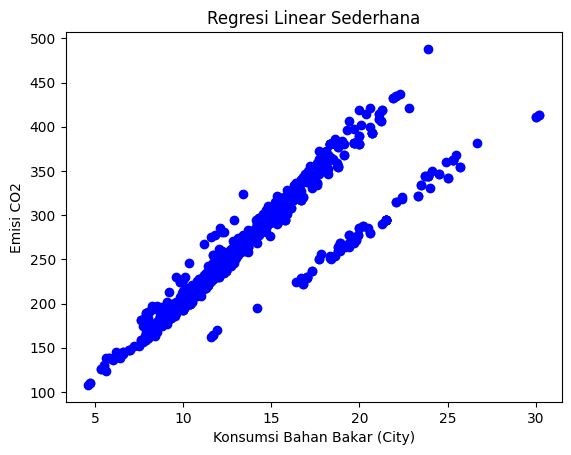

In [ ]:
# visualisasi plot regresi linear sederhana 
plt.scatter(cdf['FUELCONSUMPTION_CITY'], cdf['CO2EMISSIONS'], color='blue')
plt.title('Regresi Linear Sederhana')
plt.xlabel('Konsumsi Bahan Bakar (City)')
plt.ylabel('Emisi CO2')
plt.show()

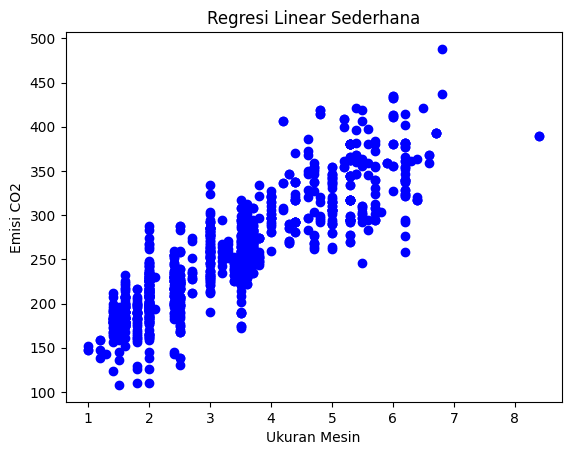

In [ ]:
# visualisasi plot regresi linear sederhana antara 'ENGINESIZE' dan 'CO2EMISSIONS'
plt.scatter(cdf['ENGINESIZE'], cdf['CO2EMISSIONS'], color='blue')
plt.title('Regresi Linear Sederhana')
plt.xlabel('Ukuran Mesin')
plt.ylabel('Emisi CO2')
plt.show()

In [ ]:
# membagi data menjadi training dan testing
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

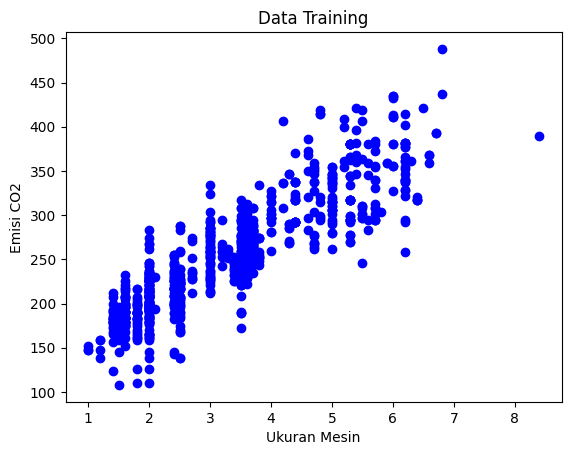

In [ ]:
# visualisasi data training antara 'ENGINESIZE' dan 'CO2EMISSIONS'
plt.scatter(train['ENGINESIZE'], train['CO2EMISSIONS'], color='blue')
plt.title('Data Training')
plt.xlabel('Ukuran Mesin')
plt.ylabel('Emisi CO2')
plt.show()

In [ ]:
# membuat model regresi linear sederhana
regr = LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(train_x, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# koefisien regresi linear sederhana
print('Koefisien: ', regr.coef_)
print('Intercept: ', regr.intercept_)

Koefisien:  [[39.31913783]]
Intercept:  [124.83322646]


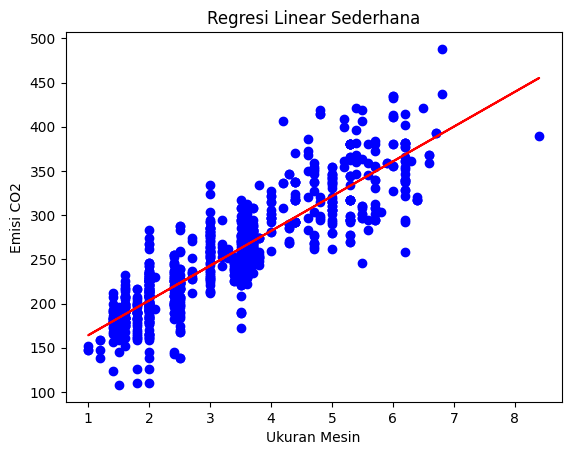

In [ ]:
# visualisasi plot regresi linear sederhana dengan data training
plt.scatter(train['ENGINESIZE'], train['CO2EMISSIONS'], color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.title('Regresi Linear Sederhana')
plt.xlabel('Ukuran Mesin')
plt.ylabel('Emisi CO2')
plt.show()